ENSF 444 Project

Crime Count

Group 28

Team Members:

Ali Awan (30219108)

Ali Chaudhary (30204228)

Tyseer Ammar Shahriar (30206937)

# ENSF 444 Project: Calgary Crime Risk Prediction

## Problem Description

The goal of this project is to help the Calgary Police Service identify areas with different levels of crime risk based on historical crime data.

Instead of predicting the exact number of crimes, we transform the problem into a classification task by grouping crime counts into low, medium, and high risk levels. This allows us to identify patterns in crime occurrences using features such as location and time, and provides more actionable insights for resource allocation and proactive policing strategies
## Objective
We will compare three machine learning models:
- Random Forest (non-linear)
- Gradient Boosting (non-linear)
- Logistic Regression (linear baseline)

The goal is to determine which model performs best at predicting whether a community falls into a low, medium, or high crime risk category.

# Importing Libraries

In [3]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import GridSearchCV

# 1.) Data Loading


The dataset used in this project contains historical crime records across different communities in Calgary from 2018-2024. It includes features such as sector, community name, crime count, year, month, resident population, etc.

We begin by loading the dataset and standardizing column names for consistency.

In [4]:
#Load dataset (make sure file is in same folder or adjust path)
df = pd.read_csv("data/Community_Crime_Statistics_20240102.csv")

#Standardize column names (lowercase and replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("Dataset loaded successfully. Shape:", df.shape)
# Preview data for first few rows
df.head()


Dataset loaded successfully. Shape: (66349, 10)


,sector,community_name,category,crime_count,resident_count,date,year,month,id,community_center_point
0,NORTHWEST,01B,Assault (Non-domestic),1,0.0,2022/11,2022,NOV,2022-NOV-01B-Assault (Non-domestic),POINT (-114.24261426059833 51.102826007628536)
1,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/06,2019,JUN,2019-JUN-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
2,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/08,2019,AUG,2019-AUG-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
3,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/03,2020,MAR,2020-MAR-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
4,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/07,2020,JUL,2020-JUL-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)


# 2.) Data Cleaning

Before training our models, we inspect the dataset for missing values and inconsistencies.

Rows containing missing values are removed to ensure data quality. Since the proportion of missing data is relatively small, this approach avoids introducing bias that could result from incorrect imputation.

In [5]:

print("Dataset Shape (Before):", df.shape)
print("\nMissing values BEFORE cleaning:")
print(df.isnull().sum())

df.info()

# Drop missing values
df = df.dropna()

print("\nDataset Shape (After):", df.shape)
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

Dataset Shape (Before): (66349, 10)

Missing values BEFORE cleaning:
sector                    30
community_name             0
category                   0
crime_count                0
resident_count            67
date                       0
year                       0
month                      0
id                         0
community_center_point    30
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66349 entries, 0 to 66348
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sector                  66319 non-null  object 
 1   community_name          66349 non-null  object 
 2   category                66349 non-null  object 
 3   crime_count             66349 non-null  int64  
 4   resident_count          66282 non-null  float64
 5   date                    66349 non-null  object 
 6   year                    66349 non-null  int64  
 7   month                   66349 non-nul

# 3.) Feature Engineering (Classification Model)

To improve model performance, we transform the target variable.

Instead of predicting the exact number of crimes, we aggregate total crimes per community per month and convert this into a classification problem.

We define three crime risk levels:
- Low risk
- Medium risk
- High risk

These categories are created using percentile-based thresholds:
- The 33rd percentile separates low and medium risk
- The 66th percentile separates medium and high risk

This ensures balanced class distributions and reduces noise in the target variable.

In [6]:
# Aggregate total crimes per community per month
df_agg = df.groupby(["sector", "community_name", "resident_count", "year", "month"], 
                     as_index=False)["crime_count"].sum()

df_agg = df_agg.rename(columns={"crime_count": "total_crime"})

# Create 3-class label: 0 = low-risk, 1 = medium-risk, 2 = high-risk
low_threshold = df_agg["total_crime"].quantile(0.33)
high_threshold = df_agg["total_crime"].quantile(0.66)

def label_risk(count):
    if count <= low_threshold:
        return 0  # low
    elif count <= high_threshold:
        return 1  # medium
    else:
        return 2  # high

df_agg["risk_level"] = df_agg["total_crime"].apply(label_risk)

print(f"Thresholds — Low: <={low_threshold}, Medium: <={high_threshold}, High: >{high_threshold}")
print(f"\nClass distribution:\n{df_agg['risk_level'].value_counts().sort_index()}")
print(f"\nAggregated dataset shape: {df_agg.shape}")
df_agg.head()


Thresholds — Low: <=5.0, Medium: <=12.0, High: >12.0

Class distribution:
risk_level
0    6754
1    5040
2    5388
Name: count, dtype: int64

Aggregated dataset shape: (17182, 7)


,sector,community_name,resident_count,year,month,total_crime,risk_level
0,CENTRE,ALTADORE,6942.0,2018,APR,11,1
1,CENTRE,ALTADORE,6942.0,2018,AUG,20,2
2,CENTRE,ALTADORE,6942.0,2018,DEC,10,1
3,CENTRE,ALTADORE,6942.0,2018,FEB,9,1
4,CENTRE,ALTADORE,6942.0,2018,JAN,10,1


In [7]:
#Features and target
features = ["sector", "community_name", "resident_count", "year", "month"]
target = "risk_level"

X = df_agg[features]
y = df_agg[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)  # Stratify to maintain class distribution in splits
print(f"Training set class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts().sort_index()}")

Training set class distribution:
risk_level
0    5403
1    4032
2    4310
Name: count, dtype: int64

Testing set class distribution:
risk_level
0    1351
1    1008
2    1078
Name: count, dtype: int64


In [8]:


categorical_features = ["sector", "community_name", "month"]
numerical_features = ["resident_count", "year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# 4.) Logistic Regression
A linear model used as a baseline for classification.

In [9]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector', 'community_name',
                                                   'month']),
                                                 ('num', StandardScaler(),
                                                  ['resident_count',
                                                   'year'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [10]:
#Define hyperparameters for grid search

param_grid_lr = {
    # Regularization strength (inverse of lambda)
    "model__C": [0.01, 0.1, 1, 10, 100],
    # L2 (Ridge) shrinks coefficients but does not eliminate them
    "model__penalty": ["l2"],
    # lbfgs supports multiclass classification and is efficient for larger datasets
    "model__solver": ["lbfgs"]
}
grid_search_lr = GridSearchCV(
    lr_model,
    param_grid_lr,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_lr.fit(X_train, y_train)

print("Best Parameters:", grid_search_lr.best_params_)

print("Best CV Score:", grid_search_lr.best_score_)



Best Parameters: {'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Score: 0.7203410238350513


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79      1351
           1       0.55      0.55      0.55      1008
           2       0.81      0.82      0.81      1078

    accuracy                           0.73      3437
   macro avg       0.72      0.72      0.72      3437
weighted avg       0.73      0.73      0.73      3437

Accuracy: 0.725923770730288


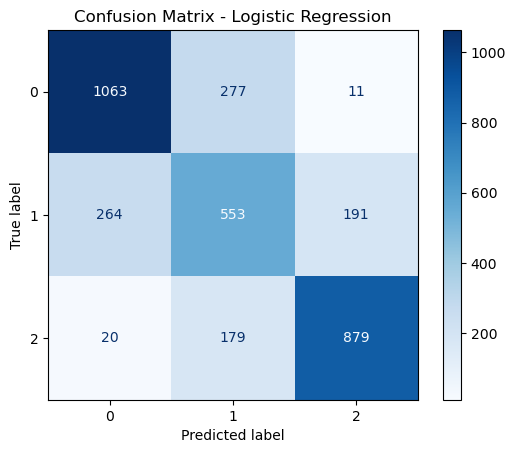

In [11]:

best_model_lr = grid_search_lr.best_estimator_

y_pred_lr = best_model_lr.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model_lr.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()



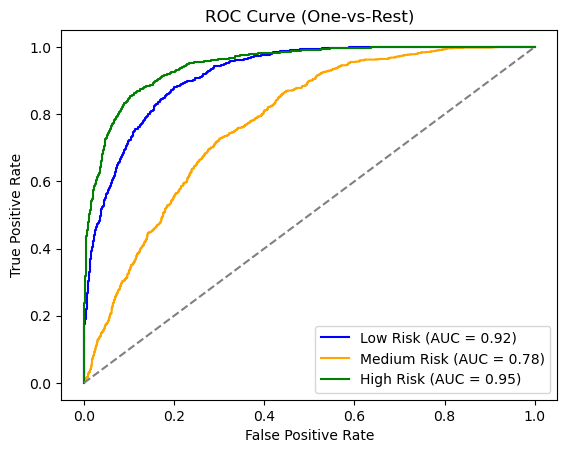

In [12]:
from sklearn.preprocessing import label_binarize

# Binarize the true labels (one column per class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities for each class
y_prob = best_model_lr.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure()
colors = ["blue", "orange", "green"]
labels = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

The Logistic Regression model achieved an overall accuracy of approximately 73%, demonstrating solid baseline performance for the classification task. The model performs well in identifying both low-risk and high-risk areas, with particularly strong results for the high-risk class, which achieved the highest recall (0.82). This indicates that the model is effective at detecting areas with elevated crime risk, an important factor for practical applications such as resource allocation. However, the model struggles with the medium-risk class, which has a lower F1-score (0.55), due to its overlap with both low and high-risk categories. Overall, Logistic Regression provides a reliable and interpretable baseline, though its linear nature limits its ability to fully capture more complex patterns in the data.

# 5.) Random Forest Classifier

In [13]:
rfc_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42
    ))
])

rfc_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector', 'community_name',
                                                   'month']),
                                                 ('num', StandardScaler(),
                                                  ['resident_count',
                                                   'year'])])),
                ('model',
                 RandomForestClassifier(max_depth=15, min_samples_leaf=2,
                                        n_estimators=200, random_state=42))])

In [14]:
param_grid_rfc = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

grid_search_rfc = GridSearchCV(
    rfc_model,
    param_grid_rfc,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_rfc.fit(X_train, y_train)

print("Best Parameters:", grid_search_rfc.best_params_)

print("Best CV Score:", grid_search_rfc.best_score_)

Best Parameters: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV Score: 0.6636264215308457


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.85      0.77      1351
           1       0.51      0.35      0.42      1008
           2       0.79      0.80      0.79      1078

    accuracy                           0.69      3437
   macro avg       0.67      0.67      0.66      3437
weighted avg       0.67      0.69      0.67      3437

Accuracy: 0.6886819901076521


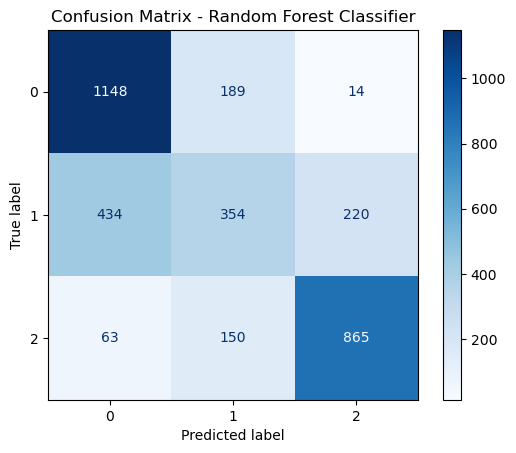

In [15]:

best_rfc_model = grid_search_rfc.best_estimator_

y_pred_rfc = best_rfc_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred_rfc))
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
cm = confusion_matrix(y_test, y_pred_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rfc_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

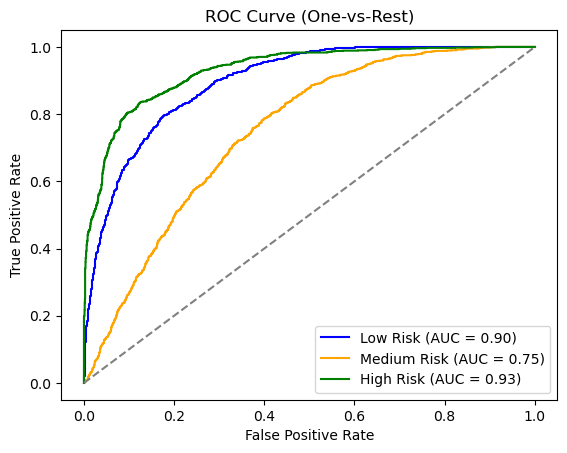

In [16]:
from sklearn.preprocessing import label_binarize

# Binarize the true labels (one column per class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities for each class
y_prob = best_rfc_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure()
colors = ["blue", "orange", "green"]
labels = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

The Random Forest classifier achieved an overall accuracy of approximately 69%, performing slightly worse than Logistic Regression. In evaluating the model, precision (how often a predicted class is correct), recall (how well the model identifies all actual instances of a class), and F1-score (a balance between precision and recall) provide deeper insight into performance across classes. The model performs well on the low-risk class, achieving a high recall of 0.85, meaning it successfully identifies most low-risk areas. It also maintains strong performance for the high-risk class, with balanced precision and recall around 0.79–0.80. However, the model struggles significantly with the medium-risk class, which has a low recall of 0.35 and F1-score of 0.42, indicating that many medium-risk areas are misclassified as either low or high risk. The support values show that each class has a similar number of samples, so this imbalance in performance is not due to uneven data distribution. Overall, while Random Forest captures non-linear relationships better, it tends to over-predict the low-risk class and has difficulty distinguishing the medium-risk category, leading to slightly lower overall performance.

# 6.) Gradient Boosted Classifer 

In [17]:
gbc_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42
    ))
])

gbc_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector', 'community_name',
                                                   'month']),
                                                 ('num', StandardScaler(),
                                                  ['resident_count',
                                                   'year'])])),
                ('model',
                 GradientBoostingClassifier(max_depth=5, max_features='sqrt',
                                            min_samples_leaf=2,
                                            n_estimators=200,
                                            random_state=42))])

In [18]:

param_grid_gbc = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_samples_leaf": [1, 2, 5],
    "model__subsample": [0.8, 1.0],
    "model__max_features": ["sqrt"],
}

grid_search_gbc = GridSearchCV(
    gbc_model,
    param_grid_gbc,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_gbc.fit(X_train, y_train)

print("Best Parameters:", grid_search_gbc.best_params_)

print("Best CV Score:", grid_search_gbc.best_score_)



Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400, 'model__subsample': 1.0}
Best CV Score: 0.7307475032700642


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80      1351
           1       0.56      0.54      0.55      1008
           2       0.82      0.83      0.82      1078

    accuracy                           0.74      3437
   macro avg       0.72      0.73      0.72      3437
weighted avg       0.73      0.74      0.73      3437

Accuracy: 0.7352342158859471


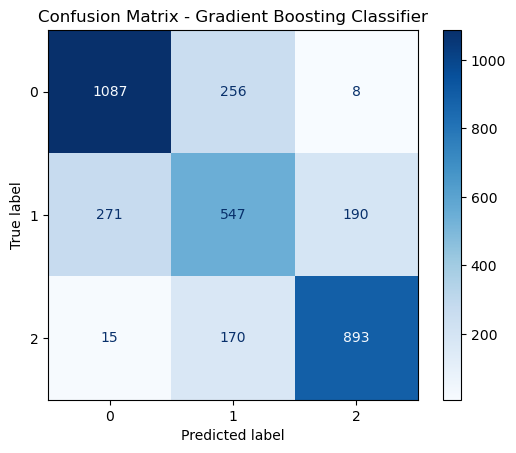

In [19]:

best_gbc_model = grid_search_gbc.best_estimator_

y_pred_gbc = best_gbc_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred_gbc))
print("Accuracy:", accuracy_score(y_test, y_pred_gbc))
cm = confusion_matrix(y_test, y_pred_gbc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_gbc_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gradient Boosting Classifier")
plt.show() 


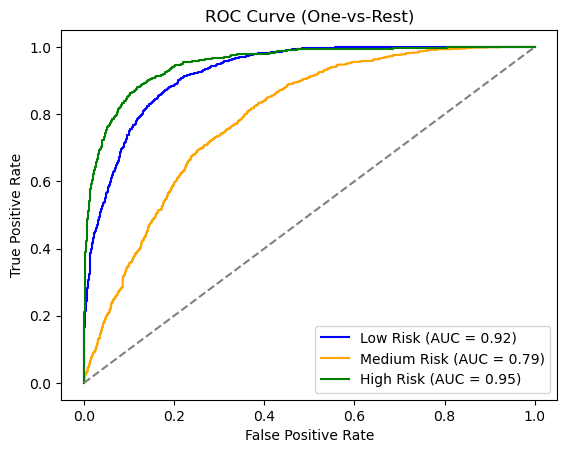

In [20]:
# Binarize the true labels (one column per class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities for each class
y_prob = best_gbc_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure()
colors = ["blue", "orange", "green"]
labels = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

The Gradient Boosting classifier achieved the highest overall accuracy of approximately 74%, making it the best-performing model among those tested. The model demonstrates strong and balanced performance for both low-risk and high-risk classes, with F1-scores of 0.80 and 0.82, respectively. In this context, precision measures how often the model’s predictions for a class are correct, while recall indicates how well the model captures all actual instances of that class. The F1-score provides a balance between these two metrics, offering an overall measure of classification quality, and support represents the number of true instances for each class. The model performs particularly well in identifying high-risk areas, achieving a recall of 0.83, which is important for real-world applications such as crime prevention. However, similar to the other models, performance on the medium-risk class remains lower (F1-score of 0.55), reflecting the inherent difficulty in distinguishing this class due to overlap with both low and high-risk categories. Overall, Gradient Boosting provides the most effective balance of accuracy and class-wise performance, making it the strongest model for this task

### Clustering Example

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("data/Community_Crime_Statistics_20240102.csv")
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Drop rows with missing values
df = df.dropna()

# Parse latitude and longitude from the point column
df["longitude"] = df["community_center_point"].str.extract(r"POINT \(([-\d.]+)").astype(float)
df["latitude"] = df["community_center_point"].str.extract(r"([\d.]+)\)$").astype(float)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (66282, 12)


,sector,community_name,category,crime_count,resident_count,date,year,month,id,community_center_point,longitude,latitude
0,NORTHWEST,01B,Assault (Non-domestic),1,0.0,2022/11,2022,NOV,2022-NOV-01B-Assault (Non-domestic),POINT (-114.24261426059833 51.102826007628536),-114.242614,51.102826
1,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/06,2019,JUN,2019-JUN-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536),-114.242614,51.102826
2,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/08,2019,AUG,2019-AUG-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536),-114.242614,51.102826
3,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/03,2020,MAR,2020-MAR-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536),-114.242614,51.102826
4,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/07,2020,JUL,2020-JUL-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536),-114.242614,51.102826


In [22]:
# Pivot: each community gets total crime counts per category
crime_pivot = df.pivot_table(
    index=["community_name", "sector", "latitude", "longitude"],
    columns="category",
    values="crime_count",
    aggfunc="sum",
    fill_value=0
).reset_index()

# Flatten multi-level column names
crime_pivot.columns.name = None

print(f"Communities: {crime_pivot.shape[0]}")
print(f"Crime categories: {crime_pivot.shape[1] - 4}")  # subtract non-feature cols
crime_pivot.head()


Communities: 287
Crime categories: 9


,community_name,sector,latitude,longitude,Assault (Non-domestic),Break & Enter - Commercial,Break & Enter - Dwelling,Break & Enter - Other Premises,Commercial Robbery,Street Robbery,Theft FROM Vehicle,Theft OF Vehicle,Violence Other (Non-domestic)
0,01B,NORTHWEST,51.102826,-114.242614,1,11,1,0,0,0,6,4,1
1,01F,NORTHWEST,51.117348,-114.261186,0,3,3,0,0,0,3,2,0
2,01K,NORTHWEST,51.168724,-114.222716,18,7,0,0,0,1,26,13,7
3,02B,NORTH,51.176021,-114.199400,0,3,0,0,0,0,0,0,0
4,02C,NORTH,51.175901,-114.176649,0,8,0,0,0,0,8,2,0


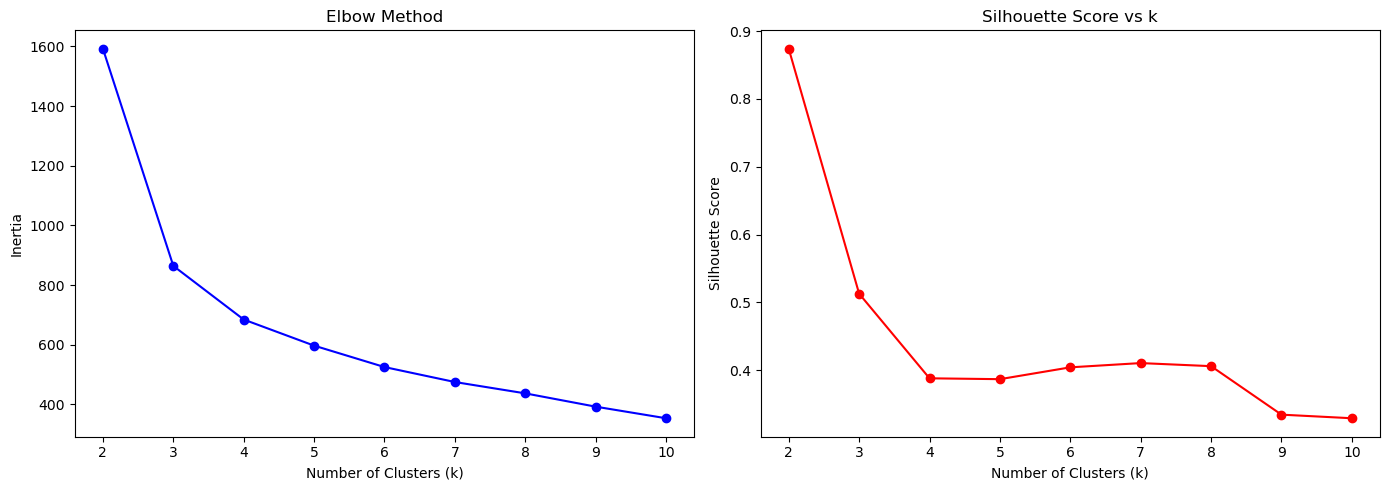

Silhouette scores:
  k=2: 0.8738
  k=3: 0.5128
  k=4: 0.3880
  k=5: 0.3868
  k=6: 0.4042
  k=7: 0.4105
  k=8: 0.4060
  k=9: 0.3345
  k=10: 0.3292


In [23]:
# Extract crime feature columns (everything except community_name, sector, lat, lon)
feature_cols = [c for c in crime_pivot.columns if c not in ["community_name", "sector", "latitude", "longitude"]]
X = crime_pivot[feature_cols]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method + silhouette scores
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(K_range, silhouettes, "ro-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [24]:
# Choose k (adjust based on elbow/silhouette results above)
optimal_k = 8  # starting with 8 to match the number of actual sectors

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
crime_pivot["cluster"] = km_final.fit_predict(X_scaled)

# Compare clusters vs actual sectors
print("Cluster vs Sector cross-tabulation:\n")
print(pd.crosstab(crime_pivot["sector"], crime_pivot["cluster"]))


Cluster vs Sector cross-tabulation:

cluster     0  1  2   3  4  5   6  7
sector                              
CENTRE     29  3  1  14  2  0  11  1
EAST       13  1  0   4  0  3   1  0
NORTH      17  1  0   1  7  1   0  0
NORTHEAST  20  3  0   9  2  9   0  0
NORTHWEST  14  2  0   2  9  1   2  0
SOUTH      35  0  0   7  9  0   1  0
SOUTHEAST  12  0  0   3  8  0   0  0
WEST       19  1  0   2  7  0   0  0


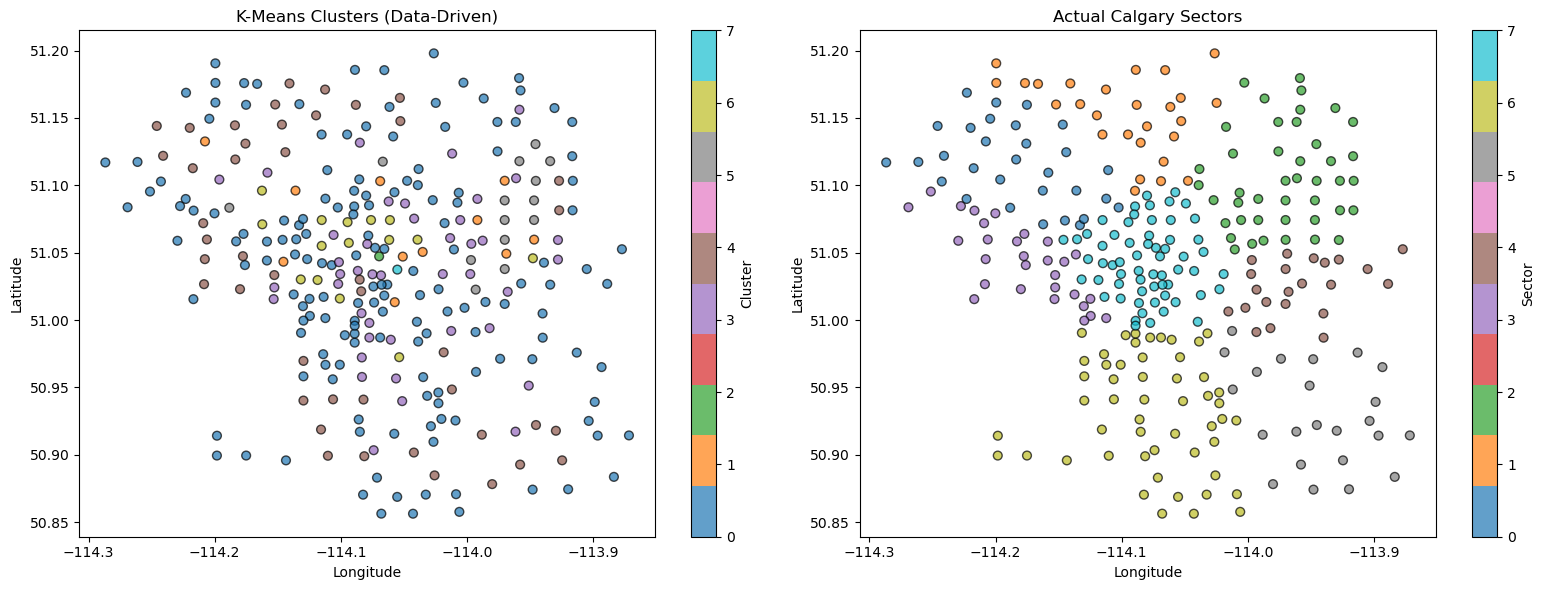

In [25]:
# Scatter plot: communities colored by cluster vs by actual sector
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(crime_pivot["longitude"], crime_pivot["latitude"],
                           c=crime_pivot["cluster"], cmap="tab10", alpha=0.7, edgecolors="k", s=40)
axes[0].set_title("K-Means Clusters (Data-Driven)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# Map sectors to numeric for coloring
sector_map = {s: i for i, s in enumerate(crime_pivot["sector"].unique())}
scatter2 = axes[1].scatter(crime_pivot["longitude"], crime_pivot["latitude"],
                           c=crime_pivot["sector"].map(sector_map), cmap="tab10", alpha=0.7, edgecolors="k", s=40)
axes[1].set_title("Actual Calgary Sectors")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(scatter2, ax=axes[1], label="Sector")

plt.tight_layout()
plt.show()
